## 1. Exploratory Data Analysis (FEMA)

This notebook explores the three core FEMA datasets to understand shapes, data quality, distributions, and relationships that will inform feature engineering and modelling.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
import os

# Setting project root folder explicitly
project_root = Path(r"C:\AMDARI PROJECTS\DISASTER RECOVERY COST PREDICTION")

# Change working directory so relative paths work
os.chdir(project_root)

print("CWD:", os.getcwd())
print("project_root:", project_root)

CWD: C:\AMDARI PROJECTS\DISASTER RECOVERY COST PREDICTION
project_root: C:\AMDARI PROJECTS\DISASTER RECOVERY COST PREDICTION


In [ ]:
# Load raw FEMA datasets
decl_path = project_root / "data" / "raw" / "disaster_declarations_summaries.csv"
pa_path   = project_root / "data" / "raw" / "public_assistance_funded_projects_details.csv"
sum_path  = project_root / "data" / "raw" / "fema_web_disaster_summaries.csv"  # when available

decl = pd.read_csv(decl_path)
pa   = pd.read_csv(pa_path)
summ = pd.read_csv(sum_path)  # comment out if not ingested yet

decl.shape, pa.shape, summ.shape

((69885, 28), (811136, 25), (3935, 14))

## 2. Data quality overview

We inspect shape, data types, missing values, and duplicate rows for each dataset.

In [5]:
def quick_data_report(df: pd.DataFrame, name: str, head_n: int = 3):
    print(f"\n{'='*70}")
    print(f"DATASET: {name}")
    print(f"{'='*70}")
    print("Shape:", df.shape)
    print("\nDtypes:")
    print(df.dtypes)

    print("\nNull counts (only columns with nulls):")
    nulls = df.isna().sum()
    nulls = nulls[nulls > 0]
    if nulls.empty:
        print("  No missing values.")
    else:
        print(nulls)

    dup_count = df.duplicated().sum()
    print(f"\nDuplicate full rows: {dup_count}")

    print("\nSample rows:")
    display(df.head(head_n))

In [6]:
# Run reports for each dataset
quick_data_report(decl, "Disaster Declarations Summaries")
quick_data_report(pa,   "Public Assistance Funded Projects Details")
quick_data_report(summ, "FEMA Web Disaster Summaries")


DATASET: Disaster Declarations Summaries
Shape: (69885, 28)

Dtypes:
femaDeclarationString       object
disasterNumber               int64
state                       object
declarationType             object
declarationDate             object
fyDeclared                   int64
incidentType                object
declarationTitle            object
ihProgramDeclared             bool
iaProgramDeclared             bool
paProgramDeclared             bool
hmProgramDeclared             bool
incidentBeginDate           object
incidentEndDate             object
disasterCloseoutDate        object
tribalRequest                 bool
fipsStateCode                int64
fipsCountyCode               int64
placeCode                    int64
designatedArea              object
declarationRequestNumber     int64
lastIAFilingDate            object
incidentId                   int64
region                       int64
designatedIncidentTypes     object
lastRefresh                 object
hash                

,femaDeclarationString,disasterNumber,state,declarationType,declarationDate,fyDeclared,incidentType,declarationTitle,ihProgramDeclared,iaProgramDeclared,...,placeCode,designatedArea,declarationRequestNumber,lastIAFilingDate,incidentId,region,designatedIncidentTypes,lastRefresh,hash,id
0,FM-5529-OR,5529,OR,FM,2024-08-09T00:00:00.000Z,2024,Fire,LEE FALLS FIRE,False,False,...,99067,Washington (County),24122,NaN,2024081001,10,R,2024-08-27T18:22:14.800Z,ae87cf3c6ed795015b714af7166c7c295b2b67c7,09e3f81a-5e16-4b72-b317-1c64e0cfa59c
1,FM-5528-OR,5528,OR,FM,2024-08-06T00:00:00.000Z,2024,Fire,ELK LANE FIRE,False,False,...,99031,Jefferson (County),24116,NaN,2024080701,10,R,2024-08-27T18:22:14.800Z,432cf0995c47e3895cea696ede5621b810460501,59983f89-30bf-4888-b21b-62e8d57d9aac
2,FM-5527-OR,5527,OR,FM,2024-08-02T00:00:00.000Z,2024,Fire,MILE MARKER 132 FIRE,False,False,...,99017,Deschutes (County),24111,NaN,2024080301,10,R,2024-08-27T18:22:14.800Z,2f21d90cb6bc64b0d4121aa3f18d852bbb4b11fa,8d13ecf0-bc2f-496b-8c9f-b2e73da832a0



DATASET: Public Assistance Funded Projects Details
Shape: (811136, 25)

Dtypes:
disasterNumber             int64
declarationDate           object
incidentType              object
pwNumber                   int64
applicationTitle          object
applicantId               object
damageCategoryCode        object
damageCategoryDescrip     object
projectStatus             object
projectProcessStep        object
projectSize               object
county                    object
countyCode                 int64
stateAbbreviation         object
stateNumberCode            int64
projectAmount            float64
federalShareObligated    float64
totalObligated           float64
lastObligationDate        object
firstObligationDate       object
mitigationAmount         float64
gmProjectId                int64
gmApplicantId              int64
lastRefresh               object
hash                      object
dtype: object

Null counts (only columns with nulls):
applicantId        5
county         1361

,disasterNumber,declarationDate,incidentType,pwNumber,applicationTitle,applicantId,damageCategoryCode,damageCategoryDescrip,projectStatus,projectProcessStep,...,projectAmount,federalShareObligated,totalObligated,lastObligationDate,firstObligationDate,mitigationAmount,gmProjectId,gmApplicantId,lastRefresh,hash
0,1239,1998-08-26T00:00:00.000Z,Severe Storm(s),1,(PW# 1) IMMEDIATE NEEDS FUNDING,465-19792-00,B,Emergency Protective Measures,Active,Project Closed Out,...,100000.0,75000.00,80340.00,1998-09-15T14:25:07.000Z,1998-09-15T14:25:07.000Z,0.0,1021769,268458,2025-11-27T15:05:59.253Z,addcfded82ae348f46ff034a4564f983a9dea897
1,1239,1998-08-26T00:00:00.000Z,Severe Storm(s),5,(PW# 5) Not Provided,465-19792-00,G,"Parks, Recreational Facilities, and Other Items",Active,Project Closed Out,...,19685.5,14764.13,15461.00,1998-09-23T08:58:52.000Z,1998-09-23T08:58:52.000Z,0.0,1062596,268458,2025-11-27T15:05:59.253Z,05c6c522b930a9c38b52a0c4b0de853e98b4cb75
2,1239,1998-08-26T00:00:00.000Z,Severe Storm(s),7,(PW# 7) Not Provided,465-19792-00,G,"Parks, Recreational Facilities, and Other Items",Active,Project Closed Out,...,26111.0,19583.25,20507.58,1998-09-23T08:58:52.000Z,1998-09-23T08:58:52.000Z,0.0,1062598,268458,2025-11-27T15:05:59.253Z,0addbfed02721821348612482bfe36d8fe587d0f



DATASET: FEMA Web Disaster Summaries
Shape: (3935, 14)

Dtypes:
disasterNumber                  int64
totalNumberIaApproved         float64
totalAmountIhpApproved        float64
totalAmountHaApproved         float64
totalAmountOnaApproved        float64
totalObligatedAmountPa        float64
totalObligatedAmountCatAb     float64
totalObligatedAmountCatC2g    float64
paLoadDate                     object
iaLoadDate                     object
totalObligatedAmountHmgp      float64
hash                           object
lastRefresh                    object
id                             object
dtype: object

Null counts (only columns with nulls):
totalNumberIaApproved         3330
totalAmountIhpApproved        3330
totalAmountHaApproved         3387
totalAmountOnaApproved        3332
totalObligatedAmountPa         950
totalObligatedAmountCatAb     1211
totalObligatedAmountCatC2g    2387
paLoadDate                     950
iaLoadDate                    3330
totalObligatedAmountHmgp      1101

,disasterNumber,totalNumberIaApproved,totalAmountIhpApproved,totalAmountHaApproved,totalAmountOnaApproved,totalObligatedAmountPa,totalObligatedAmountCatAb,totalObligatedAmountCatC2g,paLoadDate,iaLoadDate,totalObligatedAmountHmgp,hash,lastRefresh,id
0,3601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3de68baba960e69da445cf822d3dd859081fb34a,2023-10-09T23:02:26.341Z,faafecca-0f76-4fb8-8ffd-b6f46f3b712c
1,3602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58566c446fce5cabbd0c3412a6bb3daa4ada1993,2023-10-09T23:02:26.341Z,b74f0dc2-fab5-42b9-acf7-c94df14d85ad
2,1802,NaN,NaN,NaN,NaN,18812748.86,13423088.38,4869890.36,2026-02-06T00:00:00.000Z,NaN,2710679.0,d5b8865b047c2db34bae425a847682fc5c952d47,2026-02-06T02:02:06.586Z,b3ae5013-d6cc-46f3-a692-18191be44083


## 3. Target variable exploration

We examine the money columns that will feed our disaster-level target: project-level totals from Public Assistance and pre-aggregated totals from FEMA Web Disaster Summaries.

In [7]:
money_cols_pa = ["federalShareObligated", "totalObligated"]
money_cols_summ = ["totalObligatedAmountPa"]

print("PA money columns:", [c for c in money_cols_pa if c in pa.columns])
print("Summaries money columns:", [c for c in money_cols_summ if c in summ.columns])

pa[money_cols_pa] = pa[money_cols_pa].apply(pd.to_numeric, errors="coerce")
summ[money_cols_summ] = summ[money_cols_summ].apply(pd.to_numeric, errors="coerce")

print("\nPA – totalObligated describe:")
print(pa["totalObligated"].describe())

print("\nSummaries – totalObligatedAmountPa describe:")
print(summ["totalObligatedAmountPa"].describe())

PA money columns: ['federalShareObligated', 'totalObligated']
Summaries money columns: ['totalObligatedAmountPa']

PA – totalObligated describe:
count    8.111360e+05
mean     3.434067e+05
std      1.354804e+07
min     -3.764233e+08
25%      3.553125e+03
50%      1.078327e+04
75%      3.905902e+04
max      8.156162e+09
Name: totalObligated, dtype: float64

Summaries – totalObligatedAmountPa describe:
count    2.985000e+03
mean     9.326632e+07
std      1.013548e+09
min     -2.349953e+07
25%      6.354001e+05
50%      3.643501e+06
75%      1.379736e+07
max      3.558784e+10
Name: totalObligatedAmountPa, dtype: float64


## 4. Target distribution (raw and log scale)

We look at the distribution of disaster-level total obligations to understand skew and extreme events.

c:\AMDARI PROJECTS\DISASTER RECOVERY COST PREDICTION\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


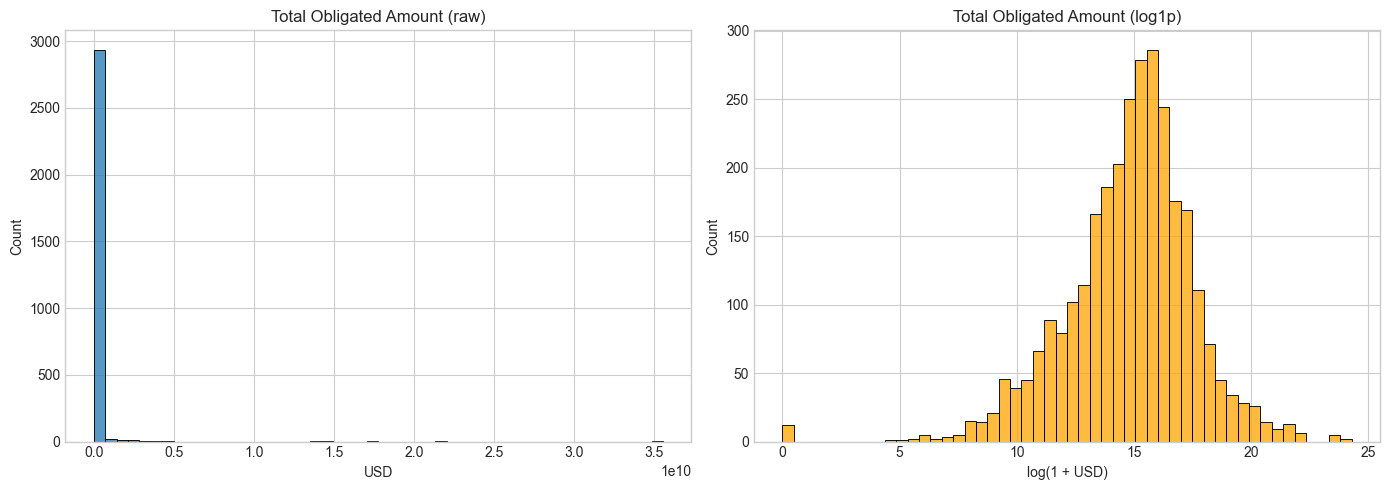

In [8]:
# Focus on disasters where FEMA Web Summaries has a PA total
target_raw = summ["totalObligatedAmountPa"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(target_raw, bins=50, ax=axes[0])
axes[0].set_title("Total Obligated Amount (raw)")
axes[0].set_xlabel("USD")

sns.histplot(np.log1p(target_raw), bins=50, ax=axes[1], color="orange")
axes[1].set_title("Total Obligated Amount (log1p)")
axes[1].set_xlabel("log(1 + USD)")

plt.tight_layout()
plt.show()

## 5. Cost breakdown by incident type

We join declarations with FEMA Web Summaries to see how recovery costs vary across disaster types.

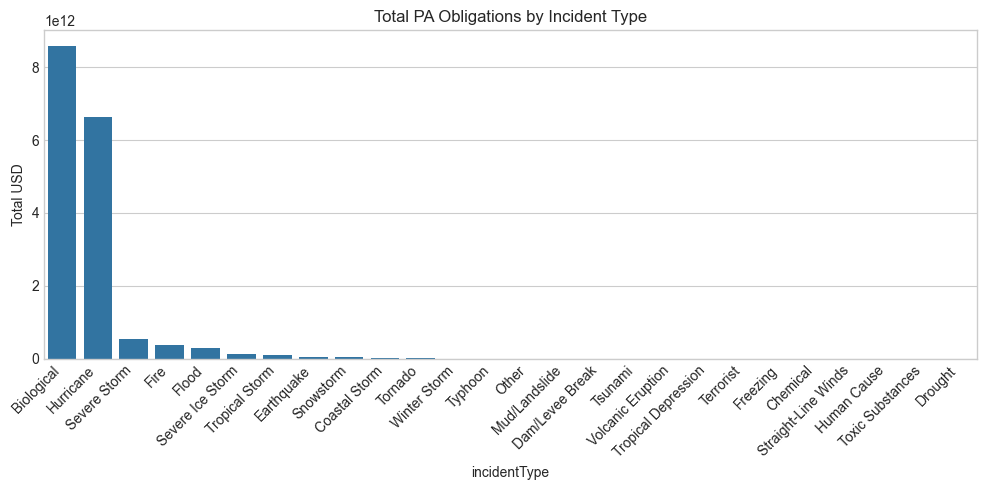

In [9]:
# Ensure keys are same type
decl["disasterNumber"] = decl["disasterNumber"].astype(str)
summ["disasterNumber"] = summ["disasterNumber"].astype(str)

# Join on disasterNumber
decl_summ = (
    decl[["disasterNumber", "incidentType", "state", "declarationDate"]]
    .merge(
        summ[["disasterNumber", "totalObligatedAmountPa"]],
        on="disasterNumber",
        how="inner",
    )
)

decl_summ = decl_summ.dropna(subset=["totalObligatedAmountPa"])

incident_cost = (
    decl_summ.groupby("incidentType", as_index=False)["totalObligatedAmountPa"]
    .sum()
    .sort_values("totalObligatedAmountPa", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=incident_cost,
    x="incidentType",
    y="totalObligatedAmountPa",
)
plt.xticks(rotation=45, ha="right")
plt.title("Total PA Obligations by Incident Type")
plt.ylabel("Total USD")
plt.tight_layout()
plt.show()

## 6. Cost breakdown by FEMA region

As a proxy for geographic pattern, we use FEMA region codes from declarations to see where costs concentrate.

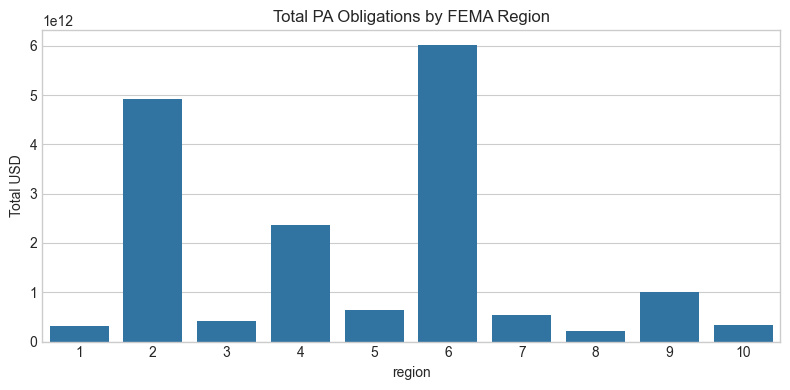

In [10]:
# Use FEMA region numeric code as a proxy; later, map to Census regions
decl_region = decl[["disasterNumber", "region"]].copy()
decl_region["disasterNumber"] = decl_region["disasterNumber"].astype(str)

decl_region_summ = decl_region.merge(
    summ[["disasterNumber", "totalObligatedAmountPa"]],
    on="disasterNumber",
    how="inner",
)
decl_region_summ = decl_region_summ.dropna(subset=["totalObligatedAmountPa"])

region_cost = (
    decl_region_summ.groupby("region", as_index=False)["totalObligatedAmountPa"]
    .sum()
    .sort_values("totalObligatedAmountPa", ascending=False)
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=region_cost,
    x="region",
    y="totalObligatedAmountPa",
)
plt.title("Total PA Obligations by FEMA Region")
plt.ylabel("Total USD")
plt.tight_layout()
plt.show()

## 7. Temporal trend: average cost per year

We examine how average disaster-level cost evolves over declaration years.

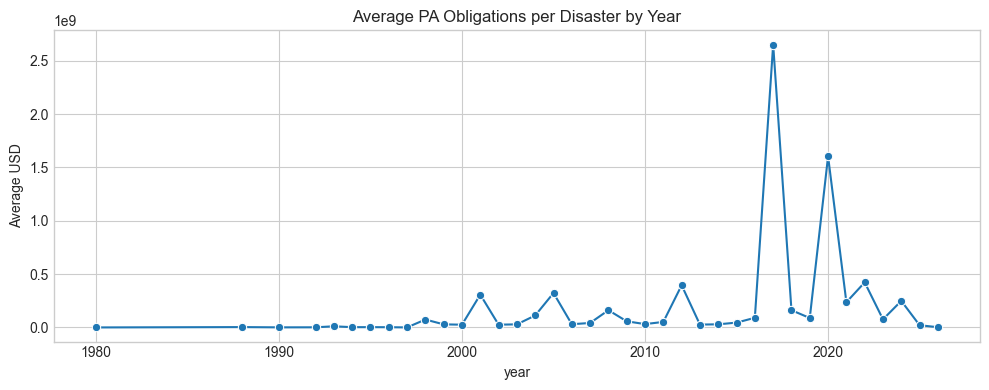

In [11]:
# Parse declarationDate to datetime and extract year
decl_summ["declarationDate"] = pd.to_datetime(decl_summ["declarationDate"], errors="coerce")
decl_summ["year"] = decl_summ["declarationDate"].dt.year

year_cost = (
    decl_summ.groupby("year", as_index=False)["totalObligatedAmountPa"]
    .mean()
    .dropna()
    .sort_values("year")
)

plt.figure(figsize=(10, 4))
sns.lineplot(
    data=year_cost,
    x="year",
    y="totalObligatedAmountPa",
    marker="o",
)
plt.title("Average PA Obligations per Disaster by Year")
plt.ylabel("Average USD")
plt.tight_layout()
plt.show()

## 8. Seasonality: cost by declaration month

We look at how disaster costs vary by month of declaration to detect seasonal patterns.

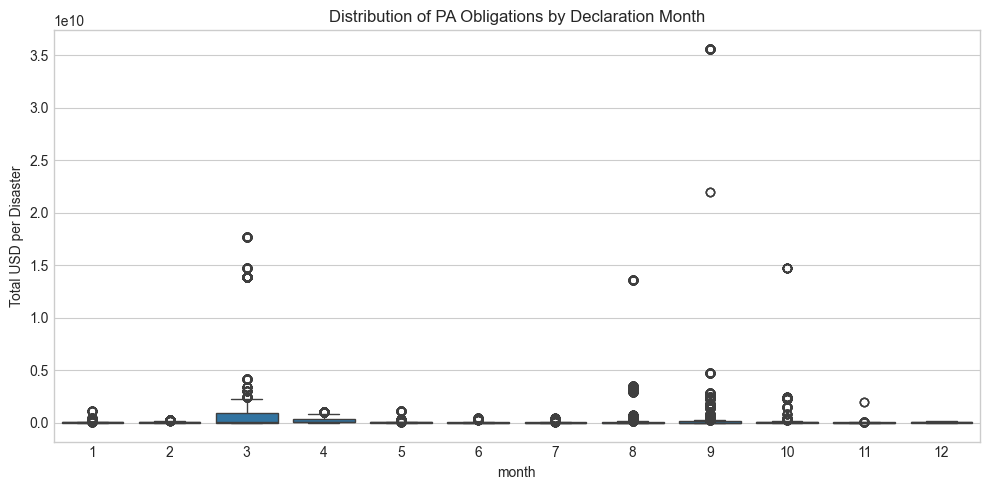

In [ ]:
decl_summ["month"] = decl_summ["declarationDate"].dt.month

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=decl_summ,
    x="month",
    y="totalObligatedAmountPa",
)
plt.title("Distribution of PA Obligations by Declaration Month")
plt.ylabel("Total USD per Disaster")
plt.tight_layout()
plt.show()

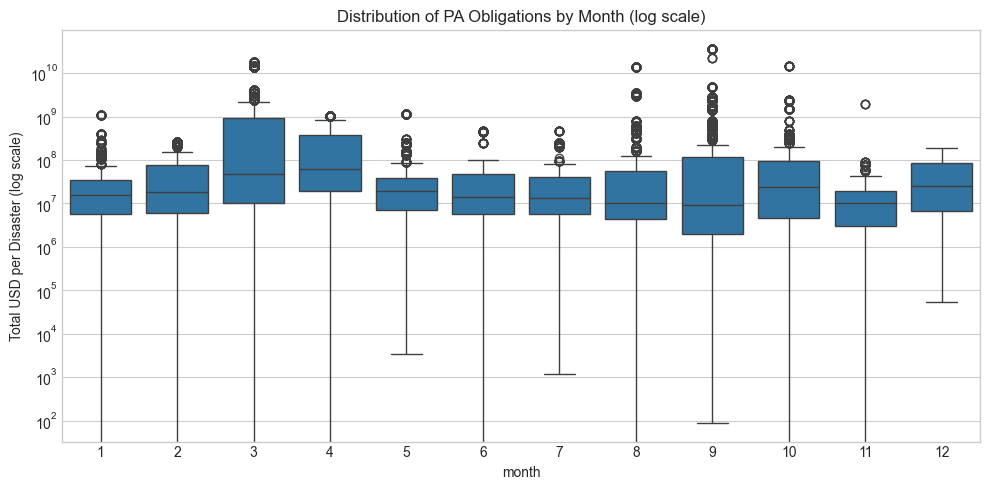

In [13]:
plt.figure(figsize=(10, 5))
ax = sns.boxplot(
    data=decl_summ,
    x="month",
    y="totalObligatedAmountPa",
)
ax.set_yscale("log")
ax.set_title("Distribution of PA Obligations by Month (log scale)")
ax.set_ylabel("Total USD per Disaster (log scale)")
plt.tight_layout()
plt.show()

## 9. Correlation heatmap of numeric columns

We inspect correlations between key numeric summary fields, including our target.

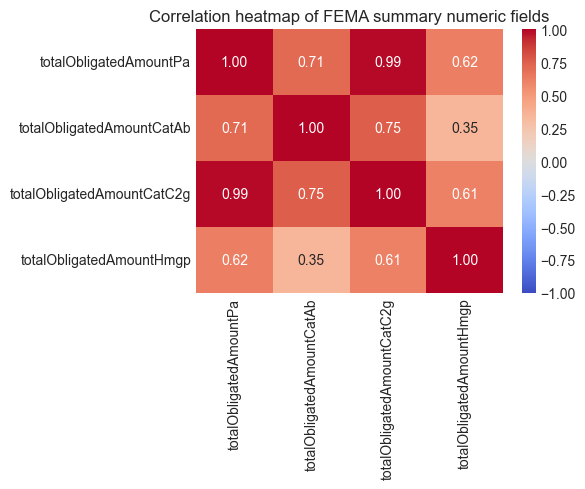

In [14]:

# Select a subset of numeric columns from summaries
numeric_cols = [
    "totalObligatedAmountPa",
    "totalObligatedAmountCatAb",
    "totalObligatedAmountCatC2g",
    "totalObligatedAmountHmgp",
]

num_df = summ[numeric_cols].apply(pd.to_numeric, errors="coerce")

corr = num_df.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
)
plt.title("Correlation heatmap of FEMA summary numeric fields")
plt.tight_layout()
plt.show()

## 10. Outlier detection on the target

We identify extremely high-cost disasters that may act as influential outliers.

In [15]:

target = target_raw.copy()  # from earlier

q1, q3 = target.quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr

high_outliers = summ[summ["totalObligatedAmountPa"] > upper].copy()
print("Upper fence:", upper)
print("Number of high-cost outlier disasters:", high_outliers.shape[0])

high_outliers = high_outliers.sort_values("totalObligatedAmountPa", ascending=False)
high_outliers[["disasterNumber", "totalObligatedAmountPa"]].head(10)

Upper fence: 33540290.75
Number of high-cost outlier disasters: 415


,disasterNumber,totalObligatedAmountPa
3609,4339,3.558784e+10
3660,4340,2.198467e+10
3587,4480,1.773248e+10
3439,4085,1.477375e+10
3514,4482,1.475192e+10
3677,4485,1.391646e+10
3467,1603,1.361331e+10
101,1391,4.732560e+09
3395,4486,4.142366e+09
3595,4611,3.517558e+09


## 11. EDA – Key Findings

### Data coverage and structure
- **Disaster Declarations (DS1)**: 69,885 rows, 28 columns, one row per declared disaster, with rich metadata on incident type, state, declaration and incident dates, and FEMA region.
- **Public Assistance Projects (DS2)**: 811,136 rows, 25 columns, many projects per disaster, containing project-level obligations (`totalObligated`, `federalShareObligated`), status, size, and damage category
- **FEMA Web Disaster Summaries (DS3)**: 3,935 rows, 14 columns, one row per disaster with pre‑aggregated totals such as `totalObligatedAmountPa`, Cat A–B and C–G breakdowns, and HMGP obligations.


### Data quality and join key
- `disasterNumber` is present in all three datasets and, after casting to string, forms a consistent join key.
- Declarations are clean overall: no duplicate rows; missing values are concentrated in end/closeout dates and some filing dates, which can be safely handled as “not yet closed / not applicable.”
- PA projects and FEMA summaries have no major structural issues; nulls are mostly in non‑critical summary fields or in IA‑related columns that we can drop for this cost‑focused model.
- Sample joins between DS1 and DS3 confirm the key works: we successfully matched multiple disasters and retrieved `totalObligatedAmountPa` alongside declaration metadata.


### Target behaviour and scale
- Disaster‑level PA obligations (`totalObligatedAmountPa`) are **extremely right‑skewed**, with a small number of disasters in the tens of billions of USD and the majority far smaller.
- A log‑transform (`log1p`) produces a much more regular, bell‑shaped distribution, which will be more stable for regression modelling and for handling extreme events.
- Outlier analysis (IQR rule) highlights a small set of very high‑cost disasters that dominate the upper tail; these events are important to keep but may need special attention (e.g., robustness checks or separate scenario analysis).


### Patterns by incident type, region, and time
- Certain **incident types** (e.g., large storm and hurricane categories) account for a disproportionate share of total PA obligations compared to others, suggesting strong predictive signal in `incidentType`.
- Costs are uneven across **FEMA regions**: a small number of regions accumulate much higher total obligations, indicating that regional exposure and hazard mix will matter for the model.
- Over time, the **average cost per disaster by declaration year** shows clear variability and hints at an upward trend in recent years, consistent with rising disaster intensity and exposure.
- By **declaration month**, costs show strong seasonality: a cluster of high‑cost disasters occurs in specific months (notably late summer and autumn), aligning with known storm and hurricane seasons.


### Implications for feature engineering
- The modelling **target** should be a disaster‑level aggregation of PA costs (e.g., sum of `totalObligated` per `disasterNumber`), most likely modelled on a log scale.
- High‑value categorical features will include `incidentType`, `state` / `region`, declaration year, and season (derived from declaration month).
- Date fields from declarations can be used to derive **incident duration** and historical frequency features, while DS3’s pre‑aggregated totals provide a useful cross‑check for our own PA‑based aggregation.
- Extreme high‑cost events are real and important; instead of dropping them, we should design the pipeline to handle them gracefully (log‑target, robust metrics, and clear documentation in the model card).